In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
img_size = (128, 128)
batch_size = 32

transform = transforms.Compose([transforms.Resize(img_size),transforms.ToTensor()])
train_dataset = datasets.ImageFolder(root="Garbage classification/train",transform=transform)
val_dataset = datasets.ImageFolder(root="Garbage classification/val",transform=transform)
test_dataset = datasets.ImageFolder(root="Garbage classification/test",transform=transform)

train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
class_names = train_dataset.classes

In [ ]:
print("Classes:", class_names)
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training Images: 2527
Validation Images: 2527
Testing Images: 2527


In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)
num_classes = len(class_names)

class GarbageCNN(nn.Module):

    def __init__(self):
        super(GarbageCNN, self).__init__()
        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(3, 32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            
            # Conv Layer 2
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))

        self.flatten = nn.Flatten()

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 30 * 30, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes))

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc_layers(x)
        return x

model = GarbageCNN().to(device)
print(model)

Using Device: cuda
GarbageCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_layers): Sequential(
    (0): Linear(in_features=57600, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 100
patience = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_loss = float('inf')
counter = 0

In [ ]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Train Acc: {train_accuracy:.2f}% "
          f"Val Acc: {val_accuracy:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        counter = 0
        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping Triggered")
            break

Epoch [1/100] Train Loss: 1.4428 Val Loss: 1.0843 Train Acc: 43.45% Val Acc: 60.07%
Epoch [2/100] Train Loss: 1.0728 Val Loss: 0.9247 Train Acc: 61.54% Val Acc: 65.85%
Epoch [3/100] Train Loss: 0.8978 Val Loss: 0.7117 Train Acc: 66.92% Val Acc: 75.94%
Epoch [4/100] Train Loss: 0.7319 Val Loss: 0.5846 Train Acc: 74.04% Val Acc: 81.32%
Epoch [5/100] Train Loss: 0.5990 Val Loss: 0.4238 Train Acc: 79.07% Val Acc: 86.74%
Epoch [6/100] Train Loss: 0.4333 Val Loss: 0.2843 Train Acc: 85.20% Val Acc: 91.77%
Epoch [7/100] Train Loss: 0.3142 Val Loss: 0.2260 Train Acc: 90.03% Val Acc: 94.42%
Epoch [8/100] Train Loss: 0.2286 Val Loss: 0.1356 Train Acc: 93.55% Val Acc: 97.39%
Epoch [9/100] Train Loss: 0.1350 Val Loss: 0.1040 Train Acc: 96.16% Val Acc: 97.55%
Epoch [10/100] Train Loss: 0.0949 Val Loss: 0.0509 Train Acc: 97.78% Val Acc: 98.81%
Epoch [11/100] Train Loss: 0.0834 Val Loss: 0.0671 Train Acc: 97.67% Val Acc: 98.30%
Epoch [12/100] Train Loss: 0.0797 Val Loss: 0.0884 Train Acc: 97.70% Val A

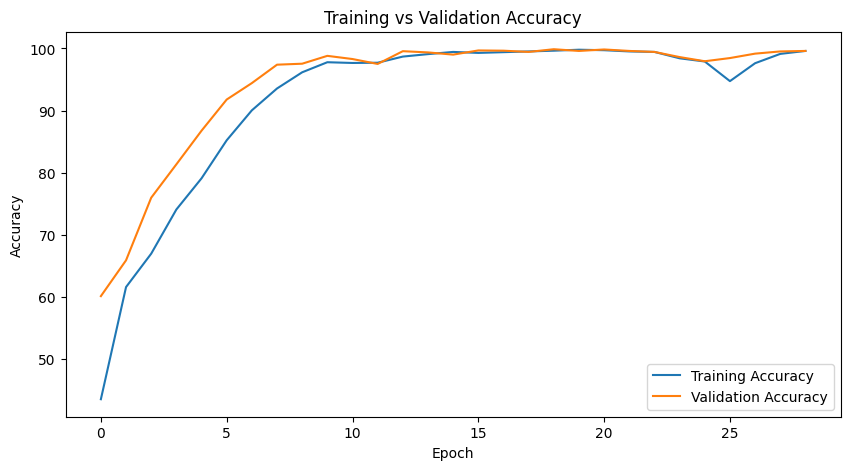

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

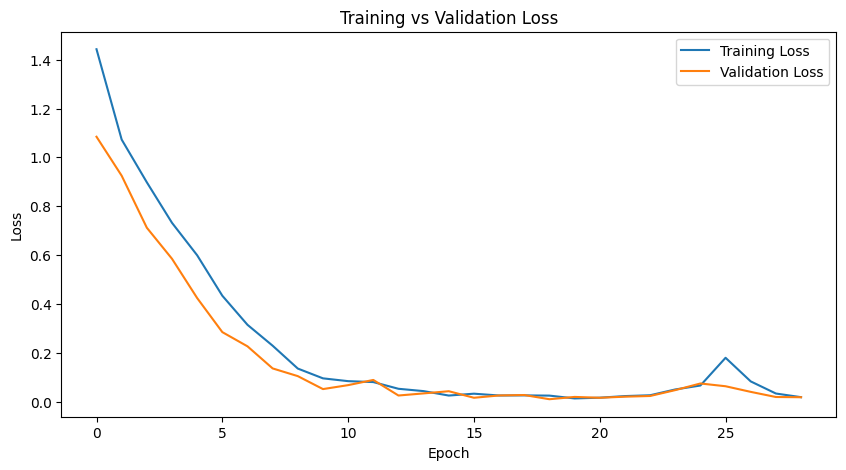

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()



No major overfitting is observed because training and validation accuracy remain very close, and both losses decrease together.



Validation loss starts increasing around Epoch 12 and rises more noticeably around Epochs 24 before early stopping at Epoch 29.

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 99.88%


BONUS

In [ ]:
from torchvision import models
import torch.nn as nn
model_transfer = models.mobilenet_v2(pretrained=True)
for param in model_transfer.parameters():
    param.requires_grad = False

num_features = model_transfer.classifier[1].in_features
model_transfer.classifier = nn.Sequential(nn.Dropout(0.2),nn.Linear(num_features, num_classes))
model_transfer = model_transfer.to(device)
print(model_transfer)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 94.5MB/s]

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_transfer.classifier.parameters(),lr=0.001)

In [ ]:
epochs = 100
patience = 10
train_losses_tl = []
val_losses_tl = []
train_acc_tl = []
val_acc_tl = []
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    model_transfer.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model_transfer(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses_tl.append(train_loss)
    train_acc_tl.append(train_acc)
    model_transfer.eval()
    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_transfer(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses_tl.append(val_loss)
    val_acc_tl.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Acc: {val_acc:.2f}%")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model_transfer.state_dict(),
                   "best_transfer_model.pth")

    else:
        counter += 1
        if counter >= patience:
            print("Early Stopping Triggered")
            break

Epoch [1/100] Train Loss: 1.0772 Val Loss: 0.6644 Train Acc: 59.56% Val Acc: 78.51%
Epoch [2/100] Train Loss: 0.6858 Val Loss: 0.5293 Train Acc: 76.61% Val Acc: 83.58%
Epoch [3/100] Train Loss: 0.6124 Val Loss: 0.4791 Train Acc: 78.71% Val Acc: 85.08%
Epoch [4/100] Train Loss: 0.5555 Val Loss: 0.4211 Train Acc: 80.97% Val Acc: 86.90%
Epoch [5/100] Train Loss: 0.5205 Val Loss: 0.3875 Train Acc: 82.11% Val Acc: 87.81%
Epoch [6/100] Train Loss: 0.4980 Val Loss: 0.3500 Train Acc: 82.03% Val Acc: 89.47%
Epoch [7/100] Train Loss: 0.4788 Val Loss: 0.3343 Train Acc: 82.59% Val Acc: 89.71%
Epoch [8/100] Train Loss: 0.4586 Val Loss: 0.3152 Train Acc: 84.76% Val Acc: 90.50%
Epoch [9/100] Train Loss: 0.4254 Val Loss: 0.3046 Train Acc: 85.24% Val Acc: 90.50%
Epoch [10/100] Train Loss: 0.4752 Val Loss: 0.2844 Train Acc: 83.38% Val Acc: 91.57%
Epoch [11/100] Train Loss: 0.4292 Val Loss: 0.2795 Train Acc: 85.08% Val Acc: 91.57%
Epoch [12/100] Train Loss: 0.4051 Val Loss: 0.2634 Train Acc: 86.07% Val A

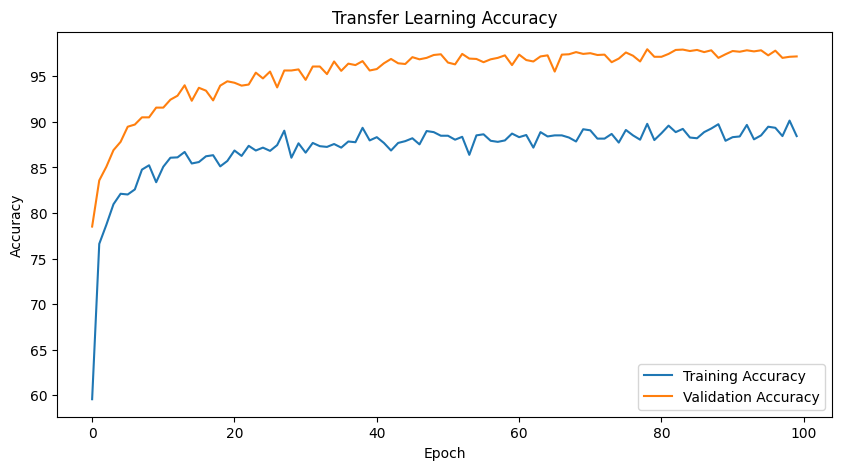

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_acc_tl, label='Training Accuracy')
plt.plot(val_acc_tl, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning Accuracy")
plt.legend()
plt.show()

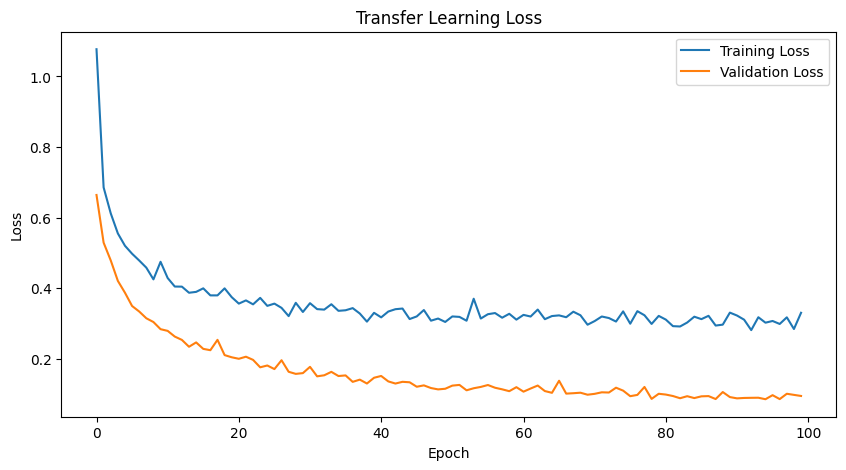

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses_tl, label='Training Loss')
plt.plot(val_losses_tl, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.show()

In [ ]:
model_transfer.load_state_dict(torch.load("best_transfer_model.pth"))
model_transfer.eval()
correct = 0
total = 0

In [5]:
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_transfer(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy = 100 * correct / total
print(f"Transfer Learning Test Acc: {test_accuracy:.2f}%")

Transfer Learning Test Acc: 97.88%
